<a href="https://colab.research.google.com/github/BioCodewithEsha/AI_and_Drug_Discovery_Course_2026/blob/main/Assignment_2_QSAR_data_curation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install chembl_webresource_client pandas matplotlib seaborn rdkit --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.1 MB/s eta 0:00:00


In [2]:
from chembl_webresource_client.new_client import new_client

# Create clients
target = new_client.target
activity = new_client.activity

# Search for the target protein
target_name = "EGFR"
selected_target = target.search(target_name)

# Pick the first (most relevant) target
target_chembl_id = selected_target[0]['target_chembl_id']
print("Target ChEMBL ID:", target_chembl_id)

# Retrieve IC50 bioactivity records
bioactivities = activity.filter(target_chembl_id=target_chembl_id, standard_type="IC50")
print("Total bioactivity records retrieved:", len(bioactivities))


Target ChEMBL ID: CHEMBL3608
Total bioactivity records retrieved: 97


In [3]:
print(selected_target[0])


{'cross_references': [], 'organism': 'Mus musculus', 'pref_name': 'Epidermal growth factor receptor', 'score': 16.0, 'species_group_flag': False, 'target_chembl_id': 'CHEMBL3608', 'target_components': [{'accession': 'Q01279', 'component_description': 'Epidermal growth factor receptor', 'component_id': 4959, 'component_type': 'PROTEIN', 'relationship': 'SINGLE PROTEIN', 'target_component_synonyms': [{'component_synonym': '2.7.10.1', 'syn_type': 'EC_NUMBER'}, {'component_synonym': 'Egfr', 'syn_type': 'GENE_SYMBOL'}, {'component_synonym': 'Epidermal growth factor receptor', 'syn_type': 'UNIPROT'}], 'target_component_xrefs': [{'xref_id': 'GO:0008283', 'xref_name': 'cell population proliferation', 'xref_src_db': 'GoProcess'}, {'xref_id': 'GO:0050673', 'xref_name': 'epithelial cell proliferation', 'xref_src_db': 'GoProcess'}, {'xref_id': 'GO:0000902', 'xref_name': 'cell morphogenesis', 'xref_src_db': 'GoProcess'}, {'xref_id': 'GO:0001892', 'xref_name': 'embryonic placenta development', 'xref

In [4]:
import pandas as pd

# Convert to DataFrame
df = pd.DataFrame(bioactivities)

# Keep only relevant columns
df = df[['molecule_chembl_id', 'canonical_smiles', 'standard_type', 'standard_value', 'standard_units']]

# Drop missing or invalid entries
df = df.dropna(subset=['canonical_smiles', 'standard_value'])

# Convert standard_value to float
df['standard_value'] = df['standard_value'].astype(float)

# Standardize units: convert nM → µM
df.loc[df['standard_units'] == 'nM', 'standard_value'] /= 1000
df['standard_units'] = 'µM'

# Optional: remove duplicates by molecule
df = df.drop_duplicates(subset=['molecule_chembl_id'])

# Save curated dataset
df.to_csv("QSAR_EGFR_data.csv", index=False)
print("Curated dataset saved with", len(df), "entries")


Curated dataset saved with 91 entries


In [5]:
def classify_ic50(value_uM):
    if value_uM <= 1:       # active ≤ 1 µM
        return "active"
    elif value_uM >= 10:    # inactive ≥ 10 µM
        return "inactive"
    else:
        return "intermediate"

df['bioactivity_class'] = df['standard_value'].apply(classify_ic50)
df.head()


,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units,bioactivity_class
0,CHEMBL292323,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,IC50,100.00,µM,inactive
1,CHEMBL304414,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,IC50,100.00,µM,inactive
2,CHEMBL62176,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,IC50,100.00,µM,inactive
3,CHEMBL62701,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,IC50,25.00,µM,inactive
4,CHEMBL137617,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,IC50,0.07,µM,active


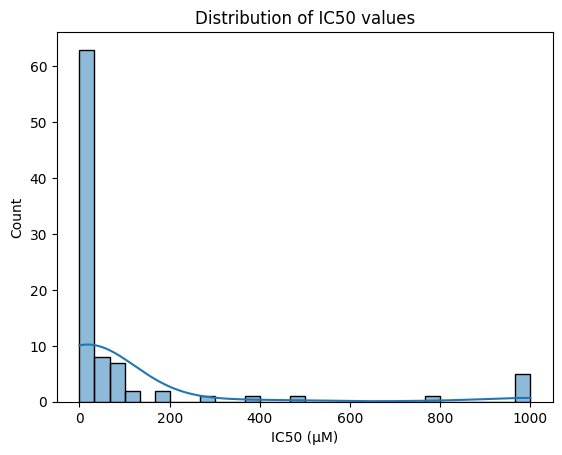

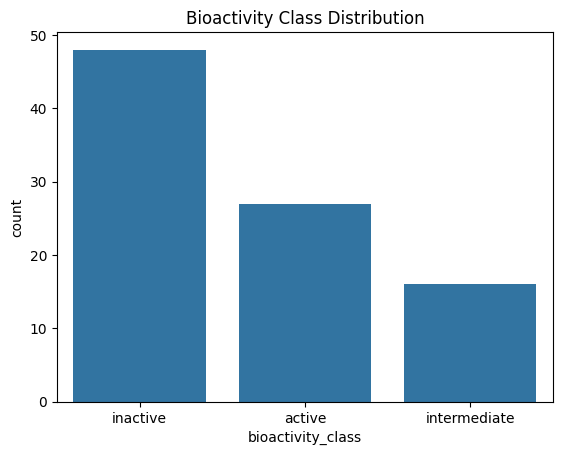

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['standard_value'], bins=30, kde=True)
plt.xlabel("IC50 (µM)")
plt.ylabel("Count")
plt.title("Distribution of IC50 values")
plt.show()

sns.countplot(x='bioactivity_class', data=df)
plt.title("Bioactivity Class Distribution")
plt.show()


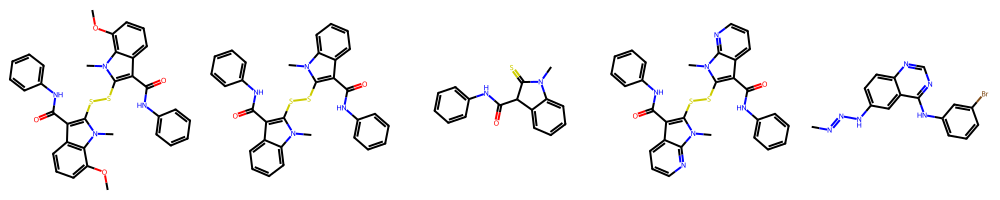

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw

# Draw first 5 molecules
mols = [Chem.MolFromSmiles(smiles) for smiles in df['canonical_smiles'].head()]
Draw.MolsToGridImage(mols, molsPerRow=5)


In [7]:
df.to_csv("QSAR_EGFR_preprocessed.csv", index=False)
